# Lab14 - Algoritmo KNN

**Materia:** Extracción de conocimiento en Bases de Datos  
**Tema:** Algoritmo K-Nearest Neighbors (KNN)  
**Dataset utilizado:** Wine (`load_wine` de sklearn)

**Objetivo:** Implementar el algoritmo KNN para clasificar vinos utilizando el dataset Wine, aplicando el flujo completo de un modelo supervisado: preparación de datos, limpieza básica, entrenamiento, predicción y evaluación del modelo.

In [1]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as np

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [2]:
# Cargamos el dataset Wine
wine = load_wine(as_frame=True)

In [3]:
# Mostramos la descripción general del dataset
print(wine.DESCR)

.. _wine_dataset:

Wine recognition dataset
------------------------

**Data Set Characteristics:**

:Number of Instances: 178
:Number of Attributes: 13 numeric, predictive attributes and the class
:Attribute Information:
    - Alcohol
    - Malic acid
    - Ash
    - Alcalinity of ash
    - Magnesium
    - Total phenols
    - Flavanoids
    - Nonflavanoid phenols
    - Proanthocyanins
    - Color intensity
    - Hue
    - OD280/OD315 of diluted wines
    - Proline
    - class:
        - class_0
        - class_1
        - class_2

:Summary Statistics:

============================= ==== ===== ======= =====
                                Min   Max   Mean     SD
============================= ==== ===== ======= =====
Alcohol:                      11.0  14.8    13.0   0.8
Malic Acid:                   0.74  5.80    2.34  1.12
Ash:                          1.36  3.23    2.36  0.27
Alcalinity of Ash:            10.6  30.0    19.5   3.3
Magnesium:                    70.0 162.0    99.7  14.3

In [4]:
# Convertimos el dataset en un DataFrame
dfWine = wine.frame

In [5]:
# Mostramos las primeras filas del dataset
dfWine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## Exploración del conjunto de datos

In [6]:
# Revisamos el tamaño del dataset
dfWine.shape

(178, 14)

In [7]:
# Revisamos las columnas del dataset
dfWine.columns

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline', 'target'],
      dtype='object')

In [8]:
# Revisamos los nombres de las clases del dataset
wine.target_names

array(['class_0', 'class_1', 'class_2'], dtype='<U7')

In [9]:
# Renombramos la columna target para que sea más entendible
dfWine.rename(columns={"target": "clase_vino"}, inplace=True)

In [10]:
# Convertimos los valores numéricos de la clase a nombres de clase
dfWine["clase_vino"] = dfWine["clase_vino"].map({
    0: "class_0",
    1: "class_1",
    2: "class_2"
})

In [11]:
# Revisamos nuevamente el dataset después de renombrar la variable objetivo
dfWine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,clase_vino
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0


## Limpieza básica de datos

In [12]:
# Verificamos si existen valores nulos
dfWine.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
clase_vino                      0
dtype: int64

In [13]:
# Verificamos si existen registros duplicados
dfWine.duplicated().sum()

np.int64(0)

In [14]:
# Revisamos estadísticas generales de las variables numéricas
dfWine.describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


## Identificar variables predictoras y variable objetivo

In [15]:
# Variables predictoras
X = dfWine.drop(columns=["clase_vino"])

In [16]:
print("Variables predictoras")
print(X.columns)

Variables predictoras
Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='object')


In [17]:
# Variable objetivo
y = dfWine["clase_vino"]

In [18]:
print("Variable objetivo")
print(y.name)
print()
print("Distribución de clases")
print(y.value_counts())

Variable objetivo
clase_vino

Distribución de clases
clase_vino
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


## Dividir los datos en prueba y entrenamiento

80 % para entrenamiento  
20 % para prueba

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [20]:
print("X train", X_train.shape)
print("X test", X_test.shape)
print("y train", y_train.shape)
print("y test", y_test.shape)

X train (142, 13)
X test (36, 13)
y train (142,)
y test (36,)


## Escalado de variables

In [21]:
# Creamos el escalador
scaler = StandardScaler()

In [22]:
# Escalamos las variables de entrenamiento
X_train_escalado = scaler.fit_transform(X_train)

In [23]:
# Escalamos las variables de prueba
X_test_escalado = scaler.transform(X_test)

In [24]:
print("Sin escalar")
print(X_train.head())

print("\nEscalado")
print(X_train_escalado[:5])

Sin escalar
     alcohol  malic_acid   ash  ...   hue  od280/od315_of_diluted_wines  proline
36     13.28        1.64  2.84  ...  1.09                          2.78    880.0
30     13.73        1.50  2.70  ...  1.19                          2.71   1285.0
26     13.39        1.77  2.62  ...  0.92                          3.22   1195.0
12     13.75        1.73  2.41  ...  1.15                          2.90   1320.0
148    13.32        3.24  2.38  ...  0.55                          1.62    650.0

[5 rows x 13 columns]

Escalado
[[ 0.38580089 -0.63787118  1.77666817 -1.22453161  0.69643032  0.52686525
   0.73229212 -0.1695489  -0.41578344 -0.16746725  0.62437819  0.2529082
   0.46772474]
 [ 0.94851892 -0.76544542  1.25317383  0.85328406  0.09178497  1.17279546
   1.33318146 -0.59045701  1.34974202  0.30530313  1.06715537  0.15104809
   1.81576773]
 [ 0.52335419 -0.51940939  0.9540342  -1.04643312 -0.44567755  0.93057163
   1.006382   -0.1695489  -0.26000178 -0.081509   -0.12834302  0.89317

## Entrenamiento del modelo KNN

En esta prueba utilizaremos **K = 3**, siguiendo una estructura similar al laboratorio anterior.

In [25]:
# Creamos el modelo KNN
modelo = KNeighborsClassifier(n_neighbors=3)

In [26]:
# Entrenamos el modelo con los datos escalados
modelo.fit(
    X_train_escalado,
    y_train
)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


## Realizando predicciones con las variables de prueba

In [27]:
# Realizamos las predicciones
prediccion = modelo.predict(X_test_escalado)

In [28]:
# Mostramos las primeras predicciones
print(prediccion[:10])

['class_0' 'class_2' 'class_0' 'class_0' 'class_1' 'class_0' 'class_0'
 'class_1' 'class_1' 'class_2']


In [29]:
# Comparación entre valores reales y valores predichos
comparacion = pd.DataFrame({
    "Clase real": y_test.values,
    "Clase predicha": prediccion
})

In [30]:
comparacion.head(30)

,Clase real,Clase predicha
0,class_0,class_0
1,class_2,class_2
2,class_0,class_0
3,class_1,class_0
4,class_1,class_1
5,class_0,class_0
6,class_0,class_0
7,class_1,class_1
8,class_1,class_1
9,class_2,class_2


## Evaluación del modelo

In [31]:
# Calculamos la exactitud del modelo
accuracy = accuracy_score(y_test, prediccion)
print(f"Accuracy / exactitud: {accuracy:.4f}")

Accuracy / exactitud: 0.9722


In [32]:
# Matriz de confusión
cm = confusion_matrix(y_test, prediccion)

In [33]:
cm_df = pd.DataFrame(
    cm,
    index=modelo.classes_,
    columns=modelo.classes_
)
cm_df

,class_0,class_1,class_2
class_0,12,0,0
class_1,1,13,0
class_2,0,0,10


## Classification report

Proporciona métricas que permiten evaluar el desempeño de cada clase: precision, recall, f1-score y support.

In [34]:
print(classification_report(y_test, prediccion))

              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       1.00      0.93      0.96        14
     class_2       1.00      1.00      1.00        10

    accuracy                           0.97        36
   macro avg       0.97      0.98      0.97        36
weighted avg       0.97      0.97      0.97        36



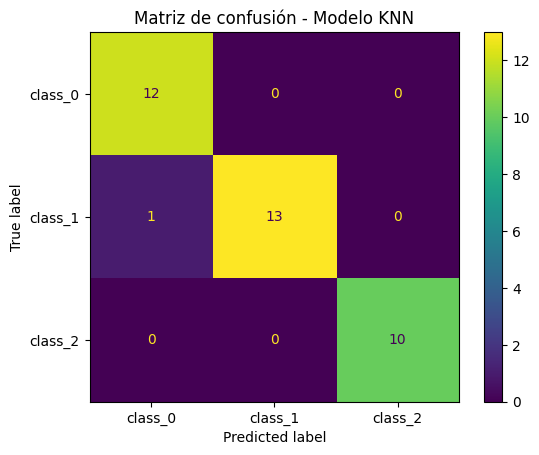

In [35]:
# Visualización de la matriz de confusión
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=modelo.classes_
)

disp.plot()
plt.title("Matriz de confusión - Modelo KNN")
plt.show()

## Conclusiones

En este laboratorio se implementó el algoritmo KNN utilizando el dataset Wine de sklearn. Primero se cargaron y exploraron los datos para conocer sus columnas, clases y distribución. Durante la limpieza se verificó que el dataset no presentara valores nulos ni duplicados, por lo que no fue necesario eliminar registros.

También se separaron las variables predictoras de la variable objetivo, y posteriormente se dividieron los datos en entrenamiento y prueba con una proporción de 80 % y 20 %. Como KNN trabaja con distancias, se aplicó escalado con `StandardScaler` para evitar que las variables con valores más grandes afectaran demasiado el resultado.

El modelo se entrenó con `K = 3` y obtuvo una exactitud alta en el conjunto de prueba. Esto indica que el algoritmo logró clasificar correctamente la mayoría de los vinos. La matriz de confusión y el reporte de clasificación permitieron observar en qué clases el modelo tuvo mejor desempeño y si existieron errores de clasificación.

En conclusión, KNN funcionó correctamente para este dataset porque las características químicas de los vinos permiten diferenciar sus clases de manera clara cuando los datos están bien preparados y escalados.